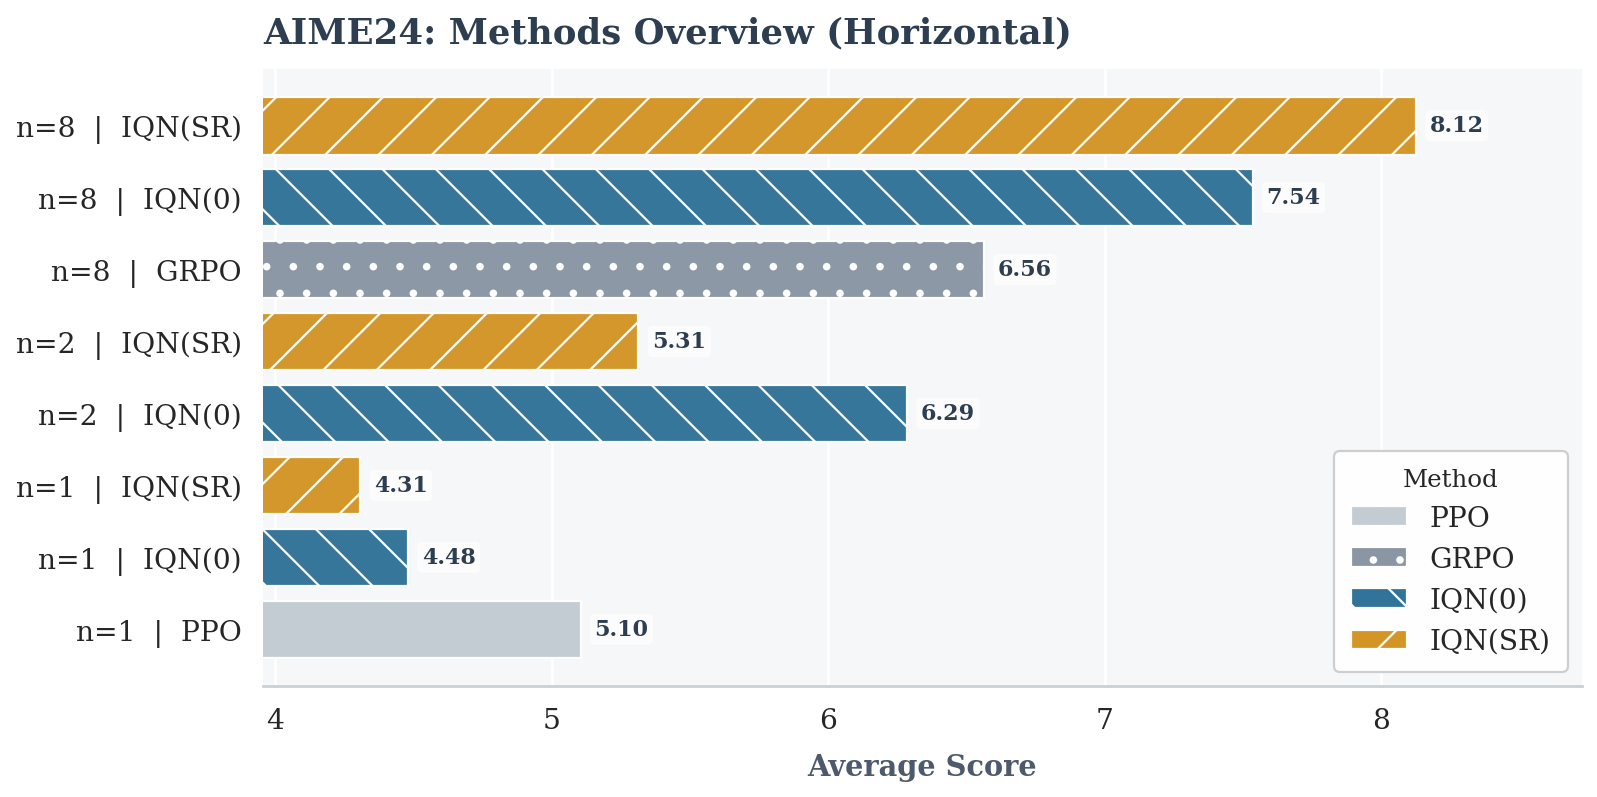

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

def plot_rolloutn_horizontal(df, *, title='AIME24: Methods Overview (Horizontal)', palette_name='slate_coral'):
    """Plot horizontal bars with emphasis on IQN methods."""
    method_order = ['PPO', 'GRPO', 'IQN(0)', 'IQN(SR)']
    group_order = ['n=1', 'n=2', 'n=8']
    df = df.copy()
    df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)
    df['Group'] = pd.Categorical(df['Group'], categories=group_order, ordered=True)

    # ====== 风格设置：简洁、统一 ======
    sns.set_theme(style='white', font_scale=1.15)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['axes.facecolor'] = '#f6f7f9'
    plt.rcParams['grid.color'] = 'white'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 1.2

    # ====== 配色（多个版本） ======
    palettes = {
        # 冷静蓝灰 + 橙色强调
        'slate_coral': {
            'PPO': '#BFC7D1',
            'GRPO': '#7A8795',
            'IQN(0)': '#4C78A8',
            'IQN(SR)': '#F28E2B',
        },
        # 更克制、学术风（蓝绿 + 金色）
        'navy_teal': {
            'PPO': '#C3CBD3',
            'GRPO': '#8A96A3',
            'IQN(0)': "#327399",
            'IQN(SR)': "#D49527",
        },
        # 高级灰基底 + 亮青强调
        'graphite_cyan': {
            'PPO': '#C7CDD3',
            'GRPO': '#6B7280',
            'IQN(0)': '#2F6F8F',
            'IQN(SR)': '#1FB6A6',
        },
    }
    palette = palettes.get(palette_name, palettes['slate_coral'])

    hatch_patterns = {
        'PPO': '',
        'GRPO': '.',
        'IQN(0)': '\\',
        'IQN(SR)': '/',

    }

    # ====== 横向条形 ======
    plot_df = df.sort_values(['Group', 'Method']).copy()
    ypos = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(10.2, 5.2), dpi=160)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True)

    bars = ax.barh(
        y=ypos,
        width=plot_df['Score'],
        color=[palette[m] for m in plot_df['Method']],
        edgecolor='white',
        linewidth=1.0,
        alpha=0.98,
    )

    for i, (score, method) in enumerate(zip(plot_df['Score'], plot_df['Method'])):
        bars[i].set_hatch(hatch_patterns[method])
        ax.text(
            score + 0.05, i,
            '{:.2f}'.format(score),
            va='center', fontsize=10, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75),
        )

    ax.set_yticks(ypos)
    ax.set_yticklabels(['{}  |  {}'.format(g, m) for g, m in zip(plot_df['Group'], plot_df['Method'])])
    ax.set_xlabel('Average Score', fontsize=13, labelpad=8, fontweight='bold', color='#4d5a6b')
    ax.set_title(title, fontsize=16, pad=12, weight='bold', loc='left', color='#2c3e50')

    xmin = df['Score'].min() - 0.35
    xmax = df['Score'].max() + 0.6
    ax.set_xlim(xmin, xmax)

    legend_handles = []
    for m in method_order:
        if m not in plot_df['Method'].unique():
            continue
        legend_handles.append(mpatches.Patch(facecolor=palette[m], hatch=hatch_patterns[m], label=m, edgecolor='white'))

    ax.legend(
        handles=legend_handles,
        title='Method',
        title_fontsize=11,
        frameon=True,
        facecolor='white',
        framealpha=0.95,
        loc='lower right',
        borderpad=0.6,
    )

    sns.despine(left=True, bottom=False)
    ax.spines['bottom'].set_color('#c8d0d8')
    plt.tight_layout()
    return fig, ax

# ====== 数据 ======
data = [
    {'Group': 'n=1', 'Method': 'PPO', 'Score': 5.104},
    {'Group': 'n=1', 'Method': 'IQN(0)', 'Score': 4.479},
    {'Group': 'n=1', 'Method': 'IQN(SR)', 'Score': 4.306},
    {'Group': 'n=2', 'Method': 'IQN(0)', 'Score': 6.285},
    {'Group': 'n=2', 'Method': 'IQN(SR)', 'Score': 5.313},
    {'Group': 'n=8', 'Method': 'GRPO', 'Score': 6.563},
    {'Group': 'n=8', 'Method': 'IQN(0)', 'Score': 7.535},
    {'Group': 'n=8', 'Method': 'IQN(SR)', 'Score': 8.125},
]
df = pd.DataFrame(data)

# 选择配色：'slate_coral' | 'navy_teal' | 'graphite_cyan'
fig, ax = plot_rolloutn_horizontal(df, palette_name='navy_teal')
plt.show()


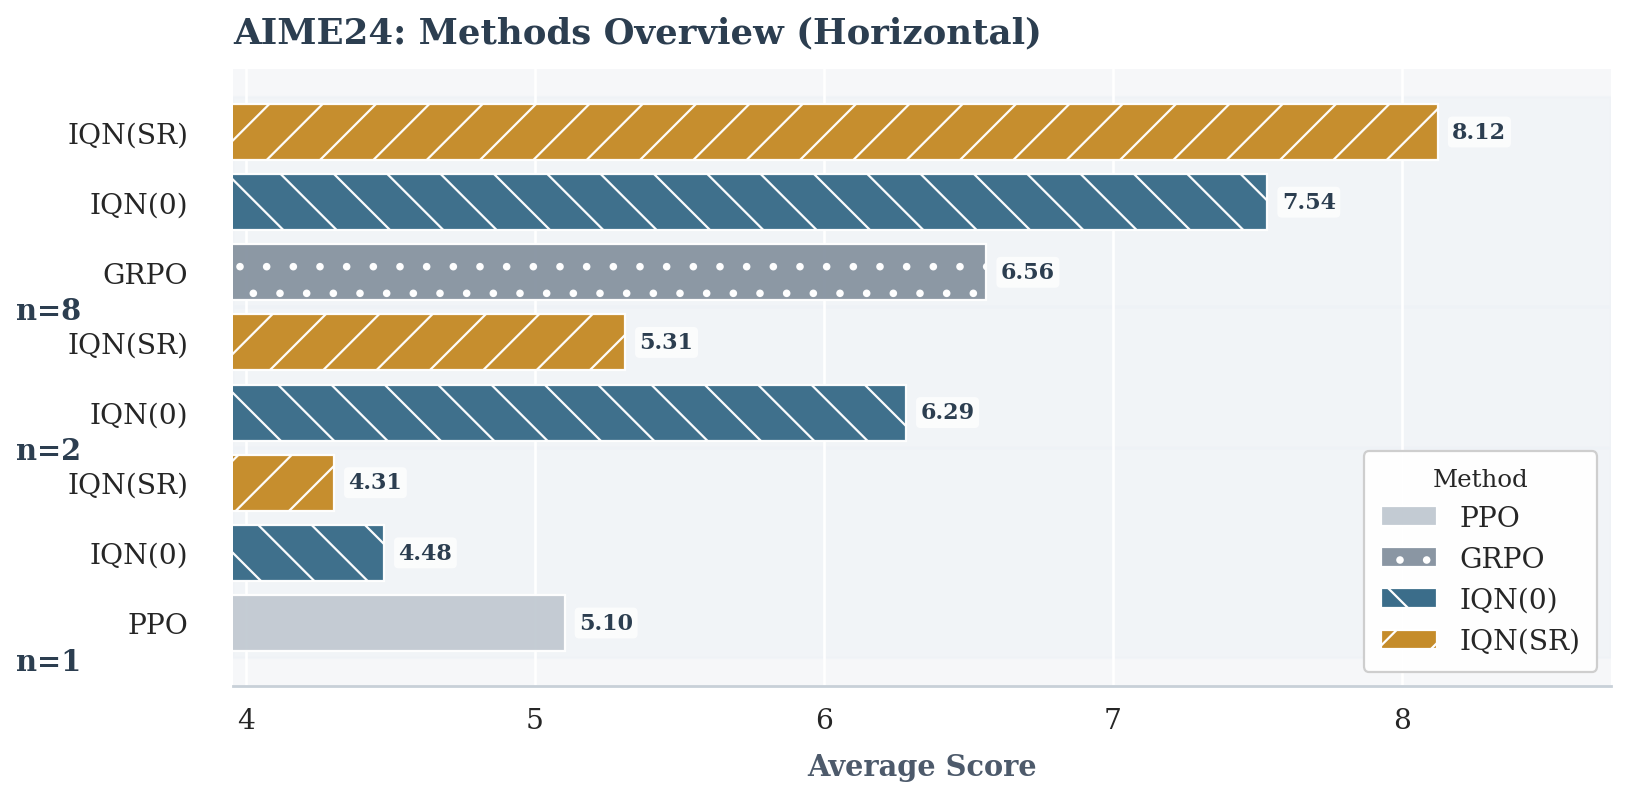

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

def plot_rolloutn_horizontal(
    df,
    *,
    title='AIME24: Methods Overview (Horizontal)',
    palette_name='slate_coral',
    show_group_panels=True,
    show_group_labels=True,
    group_label_mode='panel',  # 'panel' (top-left) or 'center'
    panel_color='#eef2f6',
    panel_alpha=0.6,
):
    """Plot horizontal bars with emphasis on IQN methods."""
    method_order = ['PPO', 'GRPO', 'IQN(0)', 'IQN(SR)']
    group_order = ['n=1', 'n=2', 'n=8']
    df = df.copy()
    df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)
    df['Group'] = pd.Categorical(df['Group'], categories=group_order, ordered=True)

    # ====== 风格设置：简洁、统一 ======
    sns.set_theme(style='white', font_scale=1.15)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['axes.facecolor'] = '#f6f7f9'
    plt.rcParams['grid.color'] = 'white'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 1.2

    # ====== 配色（多个版本） ======
    palettes = {
        # 冷静蓝灰 + 橙色强调
        'slate_coral': {
            'PPO': '#BFC7D1',
            'GRPO': '#7A8795',
            'IQN(0)': '#4C78A8',
            'IQN(SR)': '#F28E2B',
        },
        # 更克制、学术风（蓝绿 + 金色）
        'navy_teal': {
            'PPO': '#C3CBD3',
            'GRPO': '#8A96A3',
            'IQN(0)': '#3B6D8A',
            'IQN(SR)': '#C58C2A',
        },
        # 高级灰基底 + 亮青强调
        'graphite_cyan': {
            'PPO': '#C7CDD3',
            'GRPO': '#6B7280',
            'IQN(0)': '#2F6F8F',
            'IQN(SR)': '#1FB6A6',
        },
    }
    palette = palettes.get(palette_name, palettes['slate_coral'])

    hatch_patterns = {
        'PPO': '',
        'GRPO': '.',
        'IQN(0)': '\\',
        'IQN(SR)': '/',

    }

    # ====== 横向条形 ======
    plot_df = df.sort_values(['Group', 'Method']).copy()
    ypos = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(10.2, 5.2), dpi=160)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True)

    # 记录 group 的 y 范围，便于画 panel 和 label
    group_spans = {}
    for g in group_order:
        idx = np.where(plot_df['Group'].values == g)[0]
        if len(idx) == 0:
            continue
        ys = int(idx.min())
        ye = int(idx.max())
        group_spans[g] = (ys, ye)

    # 淡色 panel（在底层）
    if show_group_panels:
        for i, (g, (ys, ye)) in enumerate(group_spans.items()):
            y0 = ys - 0.5
            y1 = ye + 0.5
            ax.axhspan(
                y0,
                y1,
                color=panel_color,
                alpha=panel_alpha if i % 2 == 0 else panel_alpha * 0.85,
                zorder=0,
            )

    bars = ax.barh(
        y=ypos,
        width=plot_df['Score'],
        color=[palette[m] for m in plot_df['Method']],
        edgecolor='white',
        linewidth=1.0,
        alpha=0.98,
        zorder=2,
    )

    for i, (score, method) in enumerate(zip(plot_df['Score'], plot_df['Method'])):
        bars[i].set_hatch(hatch_patterns[method])
        ax.text(
            score + 0.05, i,
            '{:.2f}'.format(score),
            va='center', fontsize=10, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75),
            zorder=3,
        )

    ax.set_yticks(ypos)
    ax.set_yticklabels(list(plot_df['Method']))
    ax.set_xlabel('Average Score', fontsize=13, labelpad=8, fontweight='bold', color='#4d5a6b')
    ax.set_title(title, fontsize=16, pad=12, weight='bold', loc='left', color='#2c3e50')

    xmin = df['Score'].min() - 0.35
    xmax = df['Score'].max() + 0.6
    ax.set_xlim(xmin, xmax)

    # --------- 让左侧留出空间（关键：不然左边挤） ----------
    if show_group_labels:
        fig.subplots_adjust(left=0.22)          # 0.18~0.26 你可以微调
        ax.tick_params(axis='y', pad=14)        # 方法名整体往右一点

        # --------- group label：y 位置避开 tick（关键：不重叠） ----------
        for g, (ys, ye) in group_spans.items():
            n_rows = int(round(ye - ys + 1))
            yc = (ys + ye) / 2.0

            if group_label_mode == 'panel':
                y_text = ys - 0.55  # panel 标题（更像分块小标题）
            else:
                # 奇数行（>=3）时，center会撞到中间那条tick：往上挪一点放到“tick间隙”
                y_text = yc - 0.35 if (n_rows >= 3 and n_rows % 2 == 1) else yc

            ax.text(
                -0.11, y_text, g,                          # x 更靠左
                transform=ax.get_yaxis_transform(),         # x轴坐标系 + y数据坐标
                ha='right', va='center',
                fontsize=13, fontweight='bold', color='#2c3e50',
                clip_on=False                                # 允许画在轴外
            )

    legend_handles = []
    for m in method_order:
        if m not in plot_df['Method'].unique():
            continue
        legend_handles.append(mpatches.Patch(facecolor=palette[m], hatch=hatch_patterns[m], label=m, edgecolor='white'))

    ax.legend(
        handles=legend_handles,
        title='Method',
        title_fontsize=11,
        frameon=True,
        facecolor='white',
        framealpha=0.95,
        loc='lower right',
        borderpad=0.6,
    )

    sns.despine(left=True, bottom=False)
    ax.spines['bottom'].set_color('#c8d0d8')
    plt.tight_layout()
    return fig, ax

# ====== 数据 ======
data = [
    {'Group': 'n=1', 'Method': 'PPO', 'Score': 5.104},
    {'Group': 'n=1', 'Method': 'IQN(0)', 'Score': 4.479},
    {'Group': 'n=1', 'Method': 'IQN(SR)', 'Score': 4.306},
    {'Group': 'n=2', 'Method': 'IQN(0)', 'Score': 6.285},
    {'Group': 'n=2', 'Method': 'IQN(SR)', 'Score': 5.313},
    {'Group': 'n=8', 'Method': 'GRPO', 'Score': 6.563},
    {'Group': 'n=8', 'Method': 'IQN(0)', 'Score': 7.535},
    {'Group': 'n=8', 'Method': 'IQN(SR)', 'Score': 8.125},
]
df = pd.DataFrame(data)

# 选择配色：'slate_coral' | 'navy_teal' | 'graphite_cyan'
fig, ax = plot_rolloutn_horizontal(df, palette_name='navy_teal')
plt.show()


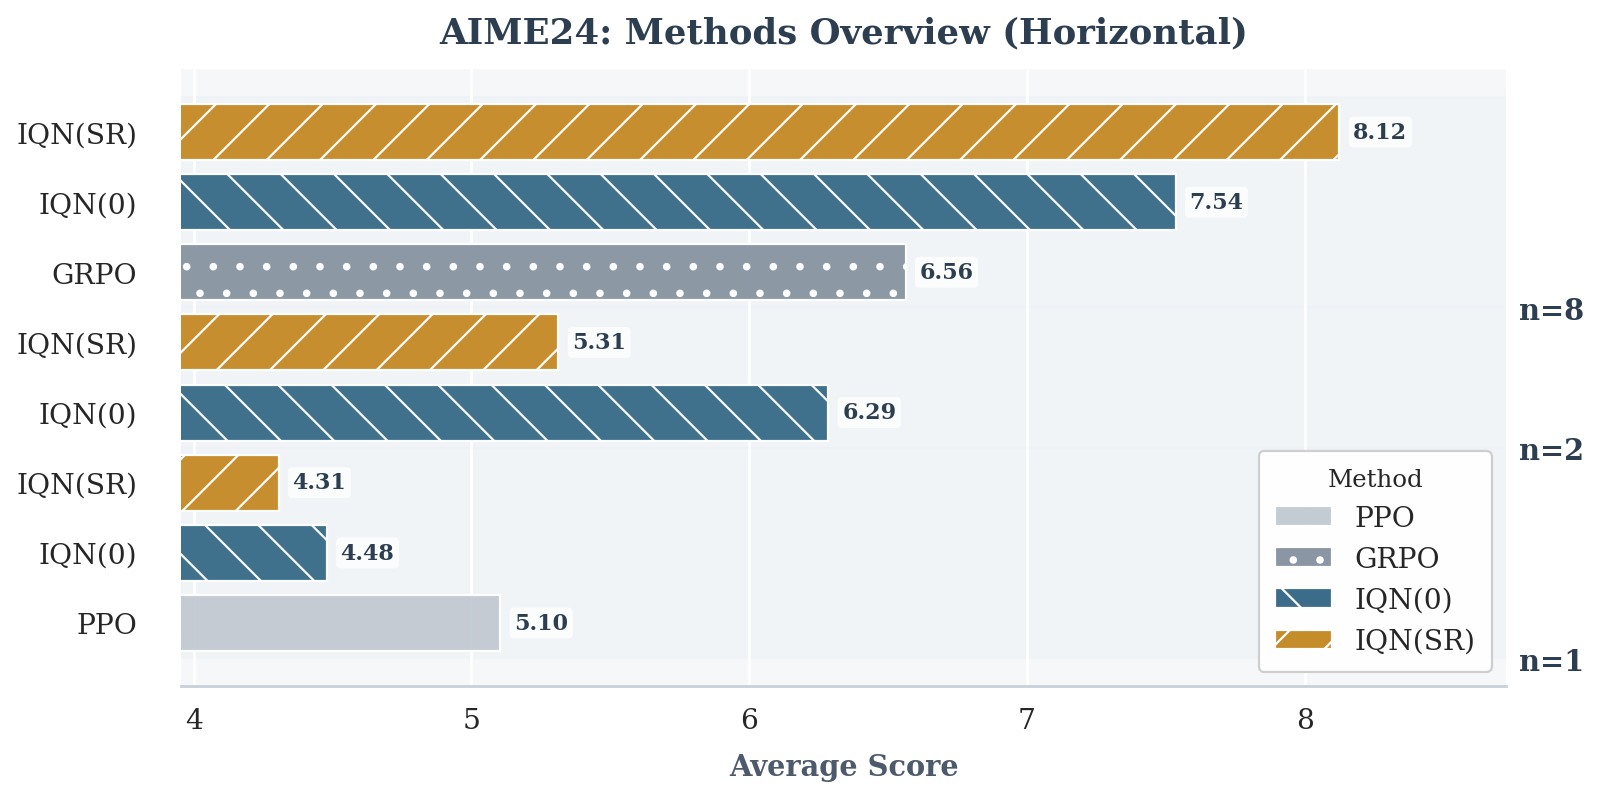

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

def plot_rolloutn_horizontal(
    df,
    *,
    title='AIME24: Methods Overview (Horizontal)',
    palette_name='slate_coral',
    show_group_panels=True,
    show_group_labels=True,
    group_label_mode='panel',      # 'panel' (top-left) or 'center'
    panel_color='#eef2f6',
    panel_alpha=0.6,
):
    method_order = ['PPO', 'GRPO', 'IQN(0)', 'IQN(SR)']
    group_order = ['n=1', 'n=2', 'n=8']
    df = df.copy()
    df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)
    df['Group'] = pd.Categorical(df['Group'], categories=group_order, ordered=True)

    sns.set_theme(style='white', font_scale=1.15)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['axes.facecolor'] = '#f6f7f9'
    plt.rcParams['grid.color'] = 'white'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 1.2

    palettes = {
        'slate_coral': {'PPO': '#BFC7D1','GRPO': '#7A8795','IQN(0)': '#4C78A8','IQN(SR)': '#F28E2B'},
        'navy_teal':   {'PPO': '#C3CBD3','GRPO': '#8A96A3','IQN(0)': '#3B6D8A','IQN(SR)': '#C58C2A'},
        'graphite_cyan':{'PPO': '#C7CDD3','GRPO': '#6B7280','IQN(0)': '#2F6F8F','IQN(SR)': '#1FB6A6'},
    }
    palette = palettes.get(palette_name, palettes['slate_coral'])

    hatch_patterns = {'PPO': '', 'GRPO': '.', 'IQN(0)': '\\', 'IQN(SR)': '/'}

    plot_df = df.sort_values(['Group', 'Method']).copy()
    ypos = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(10.2, 5.2), dpi=160)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True)

    group_spans = {}
    for g in group_order:
        idx = np.where(plot_df['Group'].values == g)[0]
        if len(idx) == 0:
            continue
        ys = int(idx.min())
        ye = int(idx.max())
        group_spans[g] = (ys, ye)

    if show_group_panels:
        for i, (g, (ys, ye)) in enumerate(group_spans.items()):
            ax.axhspan(ys - 0.5, ye + 0.5,
                       color=panel_color,
                       alpha=panel_alpha if i % 2 == 0 else panel_alpha * 0.85,
                       zorder=0)

    bars = ax.barh(
        y=ypos,
        width=plot_df['Score'],
        color=[palette[m] for m in plot_df['Method']],
        edgecolor='white',
        linewidth=1.0,
        alpha=0.98,
        zorder=2,
    )

    for i, (score, method) in enumerate(zip(plot_df['Score'], plot_df['Method'])):
        bars[i].set_hatch(hatch_patterns[method])
        ax.text(
            score + 0.05, i,
            '{:.2f}'.format(score),
            va='center', fontsize=10, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75),
            zorder=3,
        )

    ax.set_yticks(ypos)
    ax.set_yticklabels(list(plot_df['Method']))
    ax.set_xlabel('Average Score', fontsize=13, labelpad=8, fontweight='bold', color='#4d5a6b')

    # ✅ 1) 标题居中（AIME24 也自然居中）
    ax.set_title(title, fontsize=16, pad=12, weight='bold', loc='center', color='#2c3e50')

    xmin = df['Score'].min() - 0.35
    xmax = df['Score'].max() + 0.6
    ax.set_xlim(xmin, xmax)

    if show_group_labels:
        # ✅ 2) 右侧要放 group label：给右边留白
        fig.subplots_adjust(left=0.22, right=0.86)
        ax.tick_params(axis='y', pad=14)

        for g, (ys, ye) in group_spans.items():
            n_rows = int(round(ye - ys + 1))
            yc = (ys + ye) / 2.0

            if group_label_mode == 'panel':
                y_text = ys - 0.55
            else:
                y_text = yc - 0.35 if (n_rows >= 3 and n_rows % 2 == 1) else yc

            # ✅ 把 n=... 放到“图的右侧”（轴外一点点）
            ax.text(
                1.01, y_text, g,
                transform=ax.get_yaxis_transform(),   # x: axes fraction, y: data
                ha='left', va='center',
                fontsize=13, fontweight='bold', color='#2c3e50',
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.85),
                clip_on=False
            )

    legend_handles = []
    for m in method_order:
        if m not in plot_df['Method'].unique():
            continue
        legend_handles.append(
            mpatches.Patch(facecolor=palette[m], hatch=hatch_patterns[m], label=m, edgecolor='white')
        )

    ax.legend(
        handles=legend_handles,
        title='Method',
        title_fontsize=11,
        frameon=True,
        facecolor='white',
        framealpha=0.95,
        loc='lower right',
        borderpad=0.6,
    )

    sns.despine(left=True, bottom=False)
    ax.spines['bottom'].set_color('#c8d0d8')
    plt.tight_layout()
    return fig, ax


# ====== 数据 ======
data = [
    {'Group': 'n=1', 'Method': 'PPO', 'Score': 5.104},
    {'Group': 'n=1', 'Method': 'IQN(0)', 'Score': 4.479},
    {'Group': 'n=1', 'Method': 'IQN(SR)', 'Score': 4.306},
    {'Group': 'n=2', 'Method': 'IQN(0)', 'Score': 6.285},
    {'Group': 'n=2', 'Method': 'IQN(SR)', 'Score': 5.313},
    {'Group': 'n=8', 'Method': 'GRPO', 'Score': 6.563},
    {'Group': 'n=8', 'Method': 'IQN(0)', 'Score': 7.535},
    {'Group': 'n=8', 'Method': 'IQN(SR)', 'Score': 8.125},
]
df = pd.DataFrame(data)

fig, ax = plot_rolloutn_horizontal(df, palette_name='navy_teal')
plt.show()


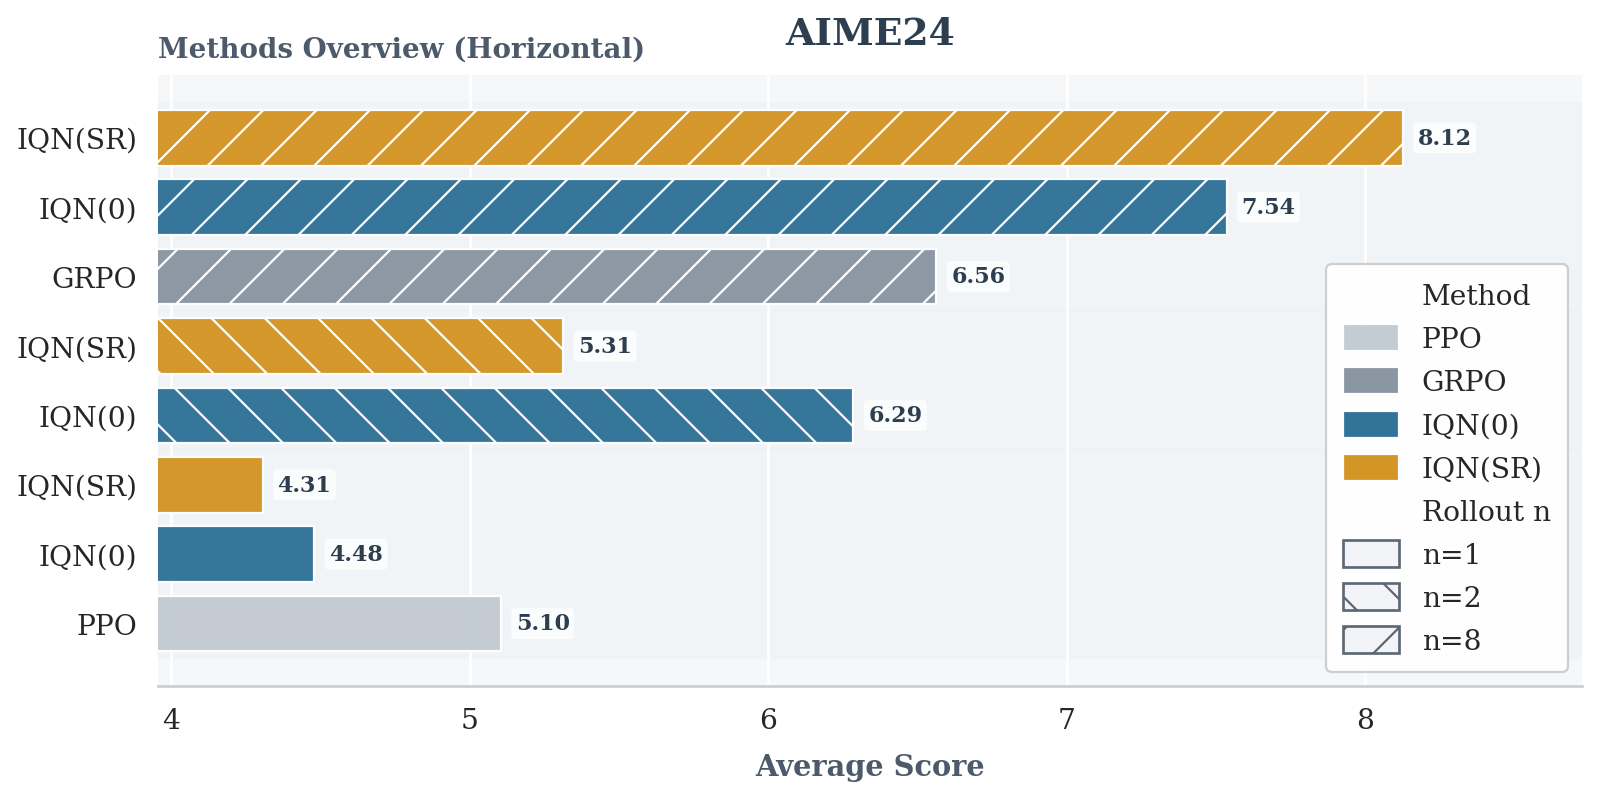

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

def plot_rolloutn_horizontal(
    df,
    *,
    title_main='AIME24',
    title_sub='Methods Overview',
    palette_name='slate_coral',
    show_group_panels=True,
    panel_color='#eef2f6',
    panel_alpha=0.6,
):
    """Horizontal bars: color by Method, hatch by Rollout n (legend only)."""
    method_order = ['PPO', 'GRPO', 'IQN(0)', 'IQN(SR)']
    group_order = ['n=1', 'n=2', 'n=8']

    df = df.copy()
    df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)
    df['Group']  = pd.Categorical(df['Group'],  categories=group_order,  ordered=True)

    # ====== 风格 ======
    sns.set_theme(style='white', font_scale=1.15)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['axes.facecolor'] = '#f6f7f9'
    plt.rcParams['grid.color'] = 'white'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 1.2

    # ====== 配色：Method 固定 ======
    palettes = {
        'slate_coral': {
            'PPO': '#BFC7D1',
            'GRPO': '#7A8795',
            'IQN(0)': '#4C78A8',
            'IQN(SR)': '#F28E2B',
        },
        'navy_teal': {
            'PPO': '#C3CBD3',
            'GRPO': '#8A96A3',
            'IQN(0)': "#327399",
            'IQN(SR)': "#D49527",
        },
        'graphite_cyan': {
            'PPO': '#C7CDD3',
            'GRPO': '#6B7280',
            'IQN(0)': '#2F6F8F',
            'IQN(SR)': '#1FB6A6',
        },
    }
    palette = palettes.get(palette_name, palettes['slate_coral'])

    # ====== hatch：Rollout n 固定一致 ======
    hatch_by_group = {
        'n=1': '',
        'n=2': '\\',
        'n=8': '/',
    }

    # ====== 数据排序 & 画图 ======
    plot_df = df.sort_values(['Group', 'Method']).copy()
    ypos = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(10.2, 5.2), dpi=160)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True)

    # 记录每个 group 的 y 范围，用于 panel
    group_spans = {}
    for g in group_order:
        idx = np.where(plot_df['Group'].values == g)[0]
        if len(idx) == 0:
            continue
        group_spans[g] = (int(idx.min()), int(idx.max()))

    # panel
    if show_group_panels:
        for i, (g, (ys, ye)) in enumerate(group_spans.items()):
            ax.axhspan(
                ys - 0.5, ye + 0.5,
                color=panel_color,
                alpha=panel_alpha if i % 2 == 0 else panel_alpha * 0.85,
                zorder=0,
            )

    # bars: color by method
    bars = ax.barh(
        y=ypos,
        width=plot_df['Score'],
        color=[palette[m] for m in plot_df['Method']],
        edgecolor='white',
        linewidth=1.0,
        alpha=0.98,
        zorder=2,
    )
    # hatch by group
    for i, g in enumerate(plot_df['Group']):
        bars[i].set_hatch(hatch_by_group.get(str(g), ''))

    # value labels
    for i, (score, method) in enumerate(zip(plot_df['Score'], plot_df['Method'])):
        ax.text(
            score + 0.05, i,
            f'{score:.2f}',
            va='center', fontsize=10, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75),
            zorder=3,
        )

    # y ticks: Method only
    ax.set_yticks(ypos)
    ax.set_yticklabels(list(plot_df['Method']))

    ax.set_xlabel('Average Score', fontsize=13, labelpad=8, fontweight='bold', color='#4d5a6b')

    # ====== 标题 ======
    ax.set_title(title_main, fontsize=17, pad=14, weight='bold', loc='center', color='#2c3e50')
    if title_sub:
        ax.text(
            0.0, 1.02, title_sub,
            transform=ax.transAxes,
            ha='left', va='bottom',
            fontsize=12.5, color='#4d5a6b', fontweight='bold'
        )

    xmin = df['Score'].min() - 0.35
    xmax = df['Score'].max() + 0.6
    ax.set_xlim(xmin, xmax)

    # ====== legend：Method + Rollout n 合并 ======
    method_handles = []
    for m in method_order:
        if m in plot_df['Method'].unique():
            method_handles.append(mpatches.Patch(facecolor=palette[m], edgecolor='white', label=m))

    group_handles = []
    for g in group_order:
        if g in plot_df['Group'].unique():
            group_handles.append(
                mpatches.Patch(
                    facecolor='#F2F4F7',
                    edgecolor='#5B6773',
                    linewidth=1.2,
                    hatch=hatch_by_group[g],
                    label=g,
                )
            )

    # 合并一个图例，并在中间插入小标题
    spacer = mpatches.Patch(facecolor='none', edgecolor='none', label='')
    handles = [spacer] + method_handles + [spacer] + group_handles
    labels  = ['Method'] + [h.get_label() for h in method_handles] + ['Rollout n'] + [h.get_label() for h in group_handles]

    ax.legend(
        handles=handles,
        labels=labels,
        frameon=True,
        facecolor='white',
        framealpha=0.95,
        loc='lower right',
        borderpad=0.6,
        handlelength=2.0,
        handleheight=1.1,
    )

    sns.despine(left=True, bottom=False)
    ax.spines['bottom'].set_color('#c8d0d8')
    plt.tight_layout()
    return fig, ax


# ====== 数据 ======
data = [
    {'Group': 'n=1', 'Method': 'PPO',     'Score': 5.104},
    {'Group': 'n=1', 'Method': 'IQN(0)',  'Score': 4.479},
    {'Group': 'n=1', 'Method': 'IQN(SR)', 'Score': 4.306},
    {'Group': 'n=2', 'Method': 'IQN(0)',  'Score': 6.285},
    {'Group': 'n=2', 'Method': 'IQN(SR)', 'Score': 5.313},
    {'Group': 'n=8', 'Method': 'GRPO',    'Score': 6.563},
    {'Group': 'n=8', 'Method': 'IQN(0)',  'Score': 7.535},
    {'Group': 'n=8', 'Method': 'IQN(SR)', 'Score': 8.125},
]
df = pd.DataFrame(data)

fig, ax = plot_rolloutn_horizontal(
    df,
    palette_name='navy_teal',
    title_main='AIME24',
    title_sub='Methods Overview (Horizontal)'
)
plt.show()


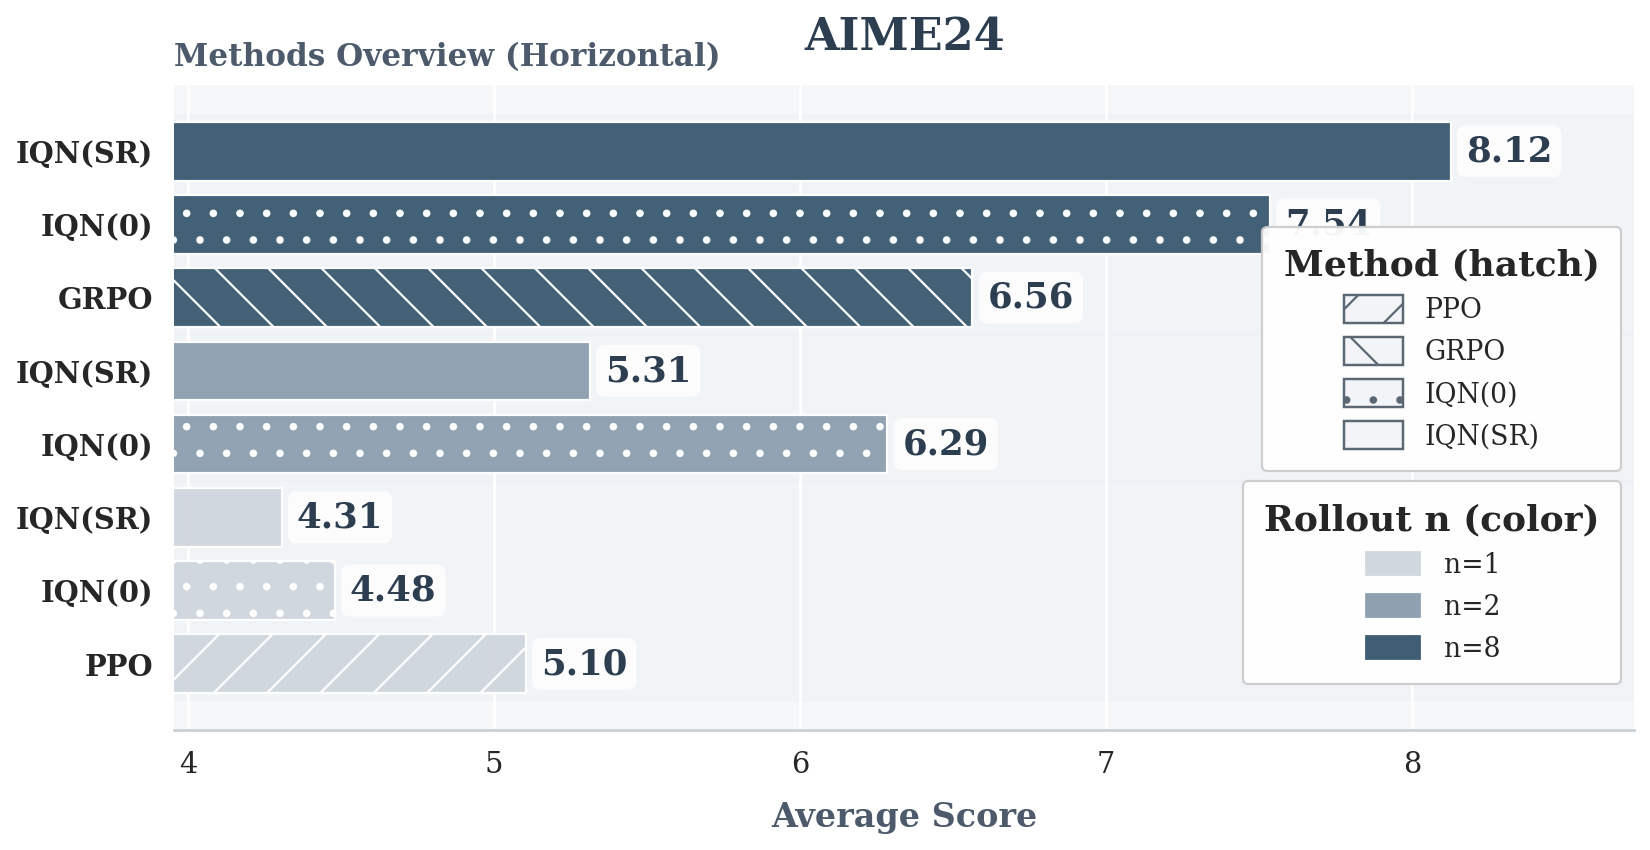

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

def plot_rolloutn_horizontal(
    df,
    *,
    title_main='AIME24',
    title_sub='Methods Overview',
    palette_name='slate_coral',
    show_group_panels=True,
    panel_color='#eef2f6',
    panel_alpha=0.6,
):
    """Horizontal bars: color by Rollout n, hatch by Method."""
    method_order = ['PPO', 'GRPO', 'IQN(0)', 'IQN(SR)']
    group_order = ['n=1', 'n=2', 'n=8']

    df = df.copy()
    df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)
    df['Group']  = pd.Categorical(df['Group'],  categories=group_order,  ordered=True)

    # ====== 风格 ======
    sns.set_theme(style='white', font_scale=1.35)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['axes.facecolor'] = '#f6f7f9'
    plt.rcParams['grid.color'] = 'white'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 1.2

    # ====== 配色：Rollout n ======
    palettes = {
        'slate_coral': {
            'n=1': '#C9D2DC',
            'n=2': '#88A2B8',
            'n=8': '#4C6E8A',
        },
        'navy_teal': {
            'n=1': '#D1D7DE',
            'n=2': '#8FA1B1',
            'n=8': '#3F5E73',
        },
        'graphite_cyan': {
            'n=1': '#D5DBE0',
            'n=2': '#8CA3B3',
            'n=8': '#2F6F8F',
        },
    }
    palette = palettes.get(palette_name, palettes['slate_coral'])

    # ====== hatch：Method 固定 / \ . ======
    hatch_by_method = {
        'PPO': '/',
        'GRPO': '\\',
        'IQN(0)': '.',
        'IQN(SR)': '',
    }

    # ====== 数据排序 & 画图 ======
    plot_df = df.sort_values(['Group', 'Method']).copy()
    ypos = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(10.6, 5.6), dpi=160)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True)

    # 记录每个 group 的 y 范围，用于 panel
    group_spans = {}
    for g in group_order:
        idx = np.where(plot_df['Group'].values == g)[0]
        if len(idx) == 0:
            continue
        group_spans[g] = (int(idx.min()), int(idx.max()))

    if show_group_panels:
        for i, (g, (ys, ye)) in enumerate(group_spans.items()):
            ax.axhspan(
                ys - 0.5, ye + 0.5,
                color=panel_color,
                alpha=panel_alpha if i % 2 == 0 else panel_alpha * 0.85,
                zorder=0,
            )

    # bars: color by group
    bars = ax.barh(
        y=ypos,
        width=plot_df['Score'],
        color=[palette[g] for g in plot_df['Group']],
        edgecolor='white',
        linewidth=1.0,
        alpha=0.98,
        zorder=2,
    )
    # hatch by method
    for i, m in enumerate(plot_df['Method']):
        bars[i].set_hatch(hatch_by_method.get(str(m), ''))

    # value labels
    for i, score in enumerate(plot_df['Score']):
        ax.text(
            score + 0.05, i,
            f'{score:.2f}',
            va='center', fontsize=16, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.8),
            zorder=3,
        )

    ax.set_yticks(ypos)
    ax.set_yticklabels(list(plot_df['Method']), fontsize=13, fontweight='bold')

    ax.set_xlabel('Average Score', fontsize=15, labelpad=10, fontweight='bold', color='#4d5a6b')

    ax.set_title(title_main, fontsize=20, pad=16, weight='bold', loc='center', color='#2c3e50')
    if title_sub:
        ax.text(
            0.0, 1.02, title_sub,
            transform=ax.transAxes,
            ha='left', va='bottom',
            fontsize=14, color='#4d5a6b', fontweight='bold'
        )

    xmin = df['Score'].min() - 0.35
    xmax = df['Score'].max() + 0.6
    ax.set_xlim(xmin, xmax)
    ax.tick_params(axis='x', labelsize=13)

    # ====== legend：Method (hatch) + Rollout n (color) ======
    method_handles = []
    for m in method_order:
        if m in plot_df['Method'].unique():
            method_handles.append(
                mpatches.Patch(facecolor='#F2F4F7', edgecolor='#5B6773', linewidth=1.1, hatch=hatch_by_method[m], label=m)
            )

    group_handles = []
    for g in group_order:
        if g in plot_df['Group'].unique():
            group_handles.append(
                mpatches.Patch(facecolor=palette[g], edgecolor='white', label=g)
            )

    # 两段式图例：上 Method（纹理），下 Rollout n（颜色）
    leg1 = ax.legend(
        handles=method_handles,
        title='Method (hatch)',
        frameon=True,
        facecolor='white',
        framealpha=0.95,
        loc='lower right',
        bbox_to_anchor=(1.0, 0.38),
        borderpad=0.8,
        handlelength=2.2,
        handleheight=1.2,
        prop={'size': 12, 'weight': 'normal'},
    )
    leg1.get_title().set_fontweight('bold')
    ax.add_artist(leg1)

    leg2 = ax.legend(
        handles=group_handles,
        title='Rollout n (color)',
        frameon=True,
        facecolor='white',
        framealpha=0.95,
        loc='lower right',
        bbox_to_anchor=(1.0, 0.05),
        borderpad=0.8,
        handlelength=2.2,
        handleheight=1.2,
        prop={'size': 12, 'weight': 'normal'},
    )
    leg2.get_title().set_fontweight('bold')

    sns.despine(left=True, bottom=False)
    ax.spines['bottom'].set_color('#c8d0d8')
    plt.tight_layout()
    return fig, ax


# ====== 数据 ======
data = [
    {'Group': 'n=1', 'Method': 'PPO',     'Score': 5.104},
    {'Group': 'n=1', 'Method': 'IQN(0)',  'Score': 4.479},
    {'Group': 'n=1', 'Method': 'IQN(SR)', 'Score': 4.306},
    {'Group': 'n=2', 'Method': 'IQN(0)',  'Score': 6.285},
    {'Group': 'n=2', 'Method': 'IQN(SR)', 'Score': 5.313},
    {'Group': 'n=8', 'Method': 'GRPO',    'Score': 6.563},
    {'Group': 'n=8', 'Method': 'IQN(0)',  'Score': 7.535},
    {'Group': 'n=8', 'Method': 'IQN(SR)', 'Score': 8.125},
]
df = pd.DataFrame(data)

fig, ax = plot_rolloutn_horizontal(
    df,
    palette_name='navy_teal',
    title_main='AIME24',
    title_sub='Methods Overview (Horizontal)'
)
plt.show()
